<a href="https://colab.research.google.com/github/Abdulrahman-Mahmoud-12/ENDO-X/blob/osama/ENDOX_Exp3_YOLOv8l.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cell 1 — Install & Download

In [ ]:
!pip install ultralytics -q

import os, zipfile

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d debeshjha1/kvasirseg

with zipfile.ZipFile('kvasirseg.zip', 'r') as zip_ref:
  zip_ref.extractall('kvasir')

print('Done!')
print(os.listdir('kvasir/Kvasir-SEG/Kvasir-SEG'))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 3.7 MB/s eta 0:00:00
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/debeshjha1/kvasirseg
License(s): copyright-authors
100% 144M/144M [00:00<00:00, 175MB/s]

Done!
['annotated_images', 'masks', 'images', 'bbox', '1911.07069.pdf']


## Cell 2 — Imports

In [ ]:
import os, cv2, csv, shutil, random, yaml, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import torch

print('PyTorch :', torch.__version__)
print('GPU     :', torch.cuda.is_available())
if torch.cuda.is_available():
  print('GPU name:', torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
PyTorch : 2.11.0+cu128
GPU     : True
GPU name: Tesla T4


## Cell 3 — Paths & Load Keys

In [ ]:
IMAGE_DIR = 'kvasir/Kvasir-SEG/Kvasir-SEG/images'
CSV_DIR   = 'kvasir/Kvasir-SEG/Kvasir-SEG/bbox'

all_keys = [f.replace('.jpg','') for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')]
print('Total images:', len(all_keys))

with open(os.path.join(CSV_DIR, all_keys[0]+'.csv'), 'r') as f:
  print('CSV sample:\n', f.read())

Total images: 1000
CSV sample:
 class_name,xmin,ymin,xmax,ymax
polyp,372,226,607,389



## Cell 4 — Build Dataset

In [ ]:
def read_bbox_csv(csv_path, img_w, img_h):
  with open(csv_path, 'r') as f:
    reader = csv.DictReader(f)
    row    = next(reader)
  x1 = float(row['xmin']); y1 = float(row['ymin'])
  x2 = float(row['xmax']); y2 = float(row['ymax'])
  bw = x2 - x1;            bh = y2 - y1
  cx = max(0., min(1., (x1 + bw/2) / img_w))
  cy = max(0., min(1., (y1 + bh/2) / img_h))
  nw = max(0., min(1., bw / img_w))
  nh = max(0., min(1., bh / img_h))
  return f'0 {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}'

BASE = 'dataset'
for split in ['train','val','test']:
  os.makedirs(f'{BASE}/images/{split}', exist_ok=True)
  os.makedirs(f'{BASE}/labels/{split}', exist_ok=True)

train_keys, temp_keys = train_test_split(all_keys, test_size=0.30, random_state=42)
val_keys,   test_keys = train_test_split(temp_keys, test_size=0.50, random_state=42)
print(f'Train:{len(train_keys)} | Val:{len(val_keys)} | Test:{len(test_keys)}')

def build_split(keys, split_name):
  for key in keys:
    img_path = os.path.join(IMAGE_DIR, key+'.jpg')
    csv_path = os.path.join(CSV_DIR,   key+'.csv')
    img = cv2.imread(img_path); h, w = img.shape[:2]
    shutil.copy(img_path, f'{BASE}/images/{split_name}/{key}.jpg')
    with open(f'{BASE}/labels/{split_name}/{key}.txt', 'w') as f:
      f.write(read_bbox_csv(csv_path, w, h) + '\n')

build_split(train_keys,'train'); build_split(val_keys,'val'); build_split(test_keys,'test')
print('Dataset ready!')

Train:700 | Val:150 | Test:150
Dataset ready!


## Cell 5 — dataset.yaml

In [ ]:
dataset_yaml = {
    'path':'/content/dataset', 'train':'images/train',
    'val':'images/val', 'test':'images/test',
    'nc':1, 'names':['polyp']
}
yaml_path = 'kvasir_detection.yaml'
with open(yaml_path,'w') as f: yaml.dump(dataset_yaml, f, default_flow_style=False)
with open(yaml_path,'r') as f: print(f.read())

names:
- polyp
nc: 1
path: /content/dataset
test: images/test
train: images/train
val: images/val



## Cell 6 — Train YOLOv8l

In [ ]:
# ── Experiment 3: YOLOv8l (Large) ──
MODEL_SIZE  = 'yolov8l.pt'   # LARGE — highest accuracy
IMG_SIZE    = 640
EPOCHS      = 80
BATCH_SIZE  = 8              # smaller batch — model أكبر
LR0         = 0.01
LRF         = 0.001
PATIENCE    = 20
CONF_THRESH = 0.25
IOU_THRESH  = 0.45

model = YOLO(MODEL_SIZE)
print(f'Model: {MODEL_SIZE} | Params: {sum(p.numel() for p in model.model.parameters()):,}')

results = model.train(
    data      = yaml_path,
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    lr0       = LR0,
    lrf       = LRF,
    patience  = PATIENCE,
    optimizer = 'Adam',
    cos_lr    = True,
    augment   = True,
    mosaic    = 1.0,
    mixup     = 0.1,
    degrees   = 10.0,
    fliplr    = 0.5,
    flipud    = 0.2,
    hsv_h     = 0.015,
    hsv_s     = 0.7,
    hsv_v     = 0.4,
    conf      = CONF_THRESH,
    iou       = IOU_THRESH,
    save      = True,
    project   = 'ENDOX_runs',
    name      = 'exp3_yolov8l',
    verbose   = True
)
print('Training complete!')

Model: yolov8l.pt | Params: 43,691,520
Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=kvasir_detection.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.45, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=e

## Cell 7 — Evaluate & Save Results

In [ ]:
best_model = YOLO('/content/runs/detect/ENDOX_runs/exp3_yolov8l/weights/best.pt')

metrics = best_model.val(
    data=yaml_path, split='test',
    imgsz=IMG_SIZE, conf=CONF_THRESH, iou=IOU_THRESH, verbose=True
)

print('\n─── Experiment 3: YOLOv8l Results ───')
print(f'mAP @ 0.5      : {metrics.box.map50:.4f}  ({metrics.box.map50*100:.2f}%)')
print(f'mAP @ 0.5:0.95 : {metrics.box.map:.4f}   ({metrics.box.map*100:.2f}%)')
print(f'Precision      : {metrics.box.mp:.4f}')
print(f'Recall         : {metrics.box.mr:.4f}')

exp3_results = {
    'experiment': 'Exp 3', 'model': 'YOLOv8l',
    'mAP50': round(metrics.box.map50, 4),
    'mAP50_95': round(metrics.box.map, 4),
    'precision': round(metrics.box.mp, 4),
    'recall': round(metrics.box.mr, 4)
}
with open('exp3_results.json', 'w') as f:
  json.dump(exp3_results, f)
print('Results saved to exp3_results.json')

Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 26.7±13.8 MB/s, size: 53.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/dataset/labels/test... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 300.8it/s 0.5s
val: New cache created: /content/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.7it/s 5.8s
                   all        150        150      0.809      0.733      0.672      0.346
Speed: 2.7ms preprocess, 31.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val

─── Experiment 3: YOLOv8l Results ───
mAP @ 0.5      : 0.6718  (67.18%

## Cell 8 — Plot & Visualize

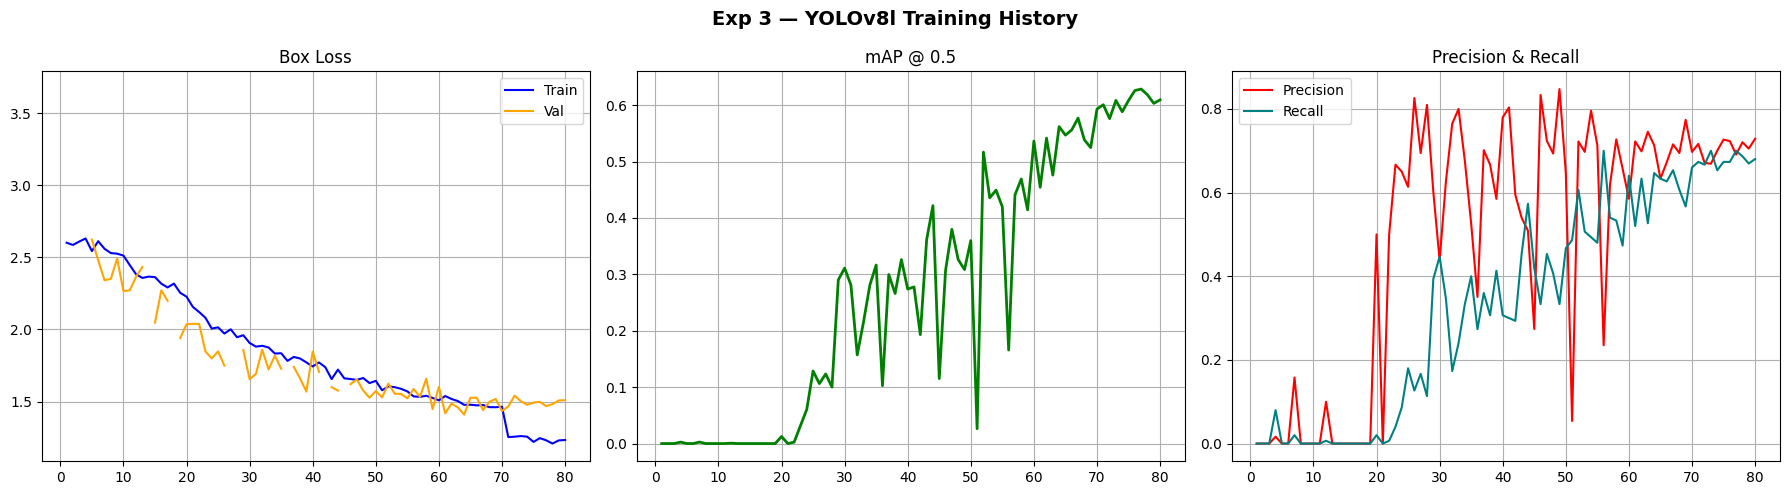

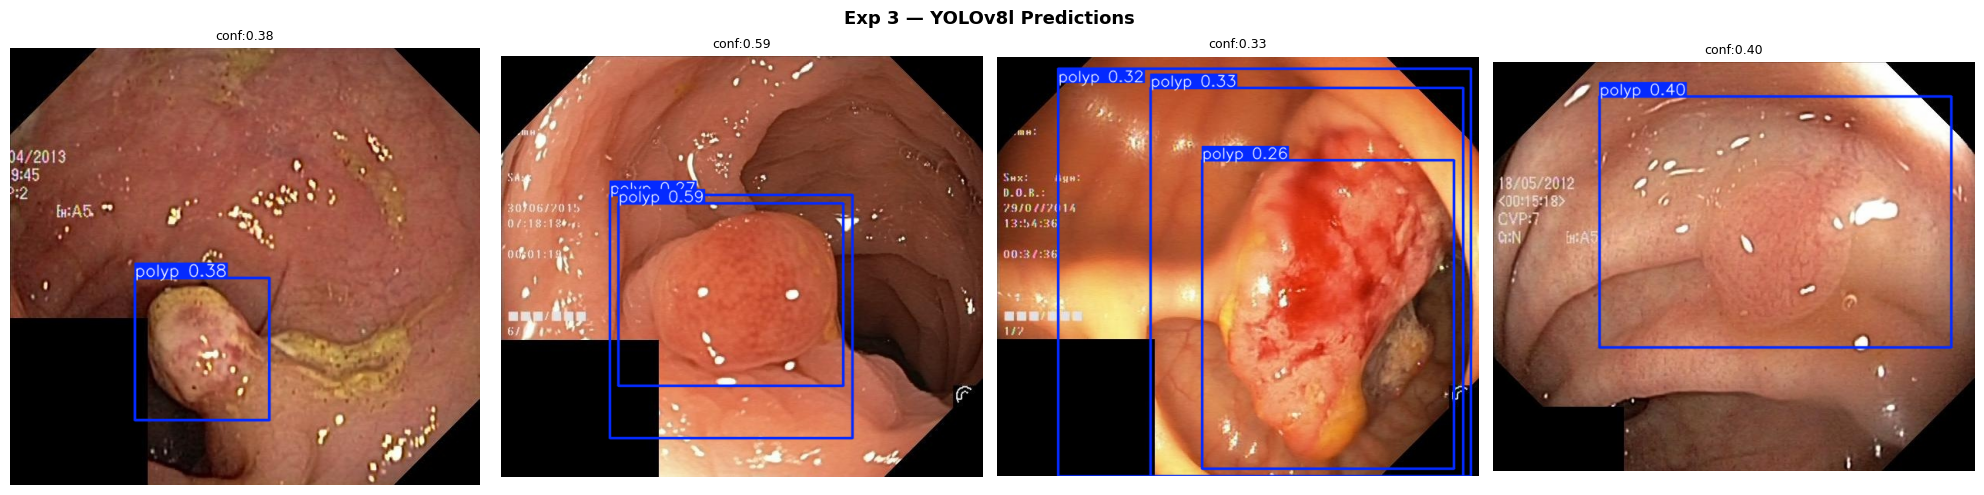

In [ ]:
df = pd.read_csv('/content/runs/detect/ENDOX_runs/exp3_yolov8l/results.csv')
df.columns = df.columns.str.strip()
epochs = df['epoch']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exp 3 — YOLOv8l Training History', fontsize=14, fontweight='bold')

axes[0].plot(epochs, df['train/box_loss'], label='Train', color='blue')
axes[0].plot(epochs, df['val/box_loss'],   label='Val',   color='orange')
axes[0].set_title('Box Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, df['metrics/mAP50(B)'], color='green', linewidth=2)
axes[1].set_title('mAP @ 0.5'); axes[1].grid(True)

axes[2].plot(epochs, df['metrics/precision(B)'], label='Precision', color='red')
axes[2].plot(epochs, df['metrics/recall(B)'],    label='Recall',    color='teal')
axes[2].set_title('Precision & Recall'); axes[2].legend(); axes[2].grid(True)

plt.tight_layout(); plt.savefig('exp3_curves.png', dpi=150); plt.show()

test_img_dir = f'{BASE}/images/test'
samples = random.sample(os.listdir(test_img_dir), 4)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Exp 3 — YOLOv8l Predictions', fontsize=13, fontweight='bold')
for i, fname in enumerate(samples):
  result  = best_model.predict(os.path.join(test_img_dir,fname), conf=CONF_THRESH, verbose=False)[0]
  plotted = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
  conf_v  = result.boxes.conf[0].item() if len(result.boxes)>0 else 0
  axes[i].imshow(plotted); axes[i].axis('off')
  axes[i].set_title(f'conf:{conf_v:.2f}' if conf_v>0 else 'No detect', fontsize=9)
plt.tight_layout(); plt.savefig('exp3_predictions.png', dpi=150); plt.show()

## Cell 9 — Save Weights

In [ ]:
shutil.copy('/content/runs/detect/ENDOX_runs/exp3_yolov8l/weights/best.pt', 'endox_exp3_yolov8l.pt')
print('Saved: endox_exp3_yolov8l.pt')
from google.colab import files
files.download('endox_exp3_yolov8l.pt')
files.download('exp3_results.json')

Saved: endox_exp3_yolov8l.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>